# Nobel Prize Analysis | 1901–2016
**Hamed Dhiaa · Python / pandas / Matplotlib**

Who appears in this historical laureate dataset, how does representation change across decades, and how does approximate award age vary by category?

A row is a **recipient-award record**, not a whole prize or a unique person. Shared prizes create multiple rows, and repeat laureates appear more than once. Findings are limited to this archive, which ends in 2016. Birth country is not citizenship, nationality or institutional affiliation. The supplied `sex` labels are analyzed as recorded; no personal attributes are inferred.

## 1. Audit the data and define the counting unit
The source mislabels four people as organizations. We correct only their analysis-time `laureate_type`, using explicit laureate IDs, while preserving the original file and source label. Official references:

- [Le Duc Tho](https://www.nobelprize.org/laureate/531)
- [Mother Teresa](https://www.nobelprize.org/prizes/peace/1979/summary/)
- [The 14th Dalai Lama](https://www.nobelprize.org/laureate/551)
- [Aung San Suu Kyi](https://www.nobelprize.org/laureate/553)

Award records include people who declined an award; they do not establish acceptance or attendance. Economics is retained under the source category label.

In [1]:
from pathlib import Path
from fractions import Fraction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold"})
BLUE, TEAL, GOLD = "#245d80", "#229b91", "#d99538"
raw = pd.read_csv("datasets/nobel.csv")
nobel = raw.copy()
correction_ids = [531, 540, 551, 553]
nobel["source_laureate_type"] = nobel["laureate_type"]
nobel.loc[nobel.laureate_id.isin(correction_ids), "laureate_type"] = "Individual"
nobel["decade"] = nobel.year.floordiv(10).mul(10)
nobel["share"] = nobel.prize_share.map(lambda value: float(Fraction(value)))
people = nobel.loc[nobel.laureate_type.eq("Individual")].copy()
organizations = nobel.loc[nobel.laureate_type.eq("Organization")].copy()
people["birth_date_parsed"] = pd.to_datetime(people.birth_date, errors="coerce")
people["approx_age"] = people.year - people.birth_date_parsed.dt.year
summary = pd.Series({"Recipient-award records": len(nobel), "Distinct year/category awards": nobel[["year","category"]].drop_duplicates().shape[0], "Unique laureate IDs (all types)": nobel.laureate_id.nunique(), "Individual award records": len(people), "Unique individuals": people.laureate_id.nunique(), "Organization award records": len(organizations)}, name="Count")
display(summary.to_frame())
display(nobel.loc[nobel.laureate_id.isin(correction_ids), ["laureate_id","full_name","source_laureate_type","laureate_type"]])
print(f"Missing birth dates among individual award records: {people.birth_date_parsed.isna().sum()}")
print(f"Known birth country: {people.birth_country.notna().sum()}/{len(people)}; known sex: {people.sex.notna().sum()}/{len(people)}")

,Count
Recipient-award records,911
Distinct year/category awards,579
Unique laureate IDs (all types),904
Individual award records,885
Unique individuals,881
Organization award records,26


,laureate_id,full_name,source_laureate_type,laureate_type
435,531,Le Duc Tho,Organization,Individual
501,540,Mother Teresa,Organization,Individual
598,551,The 14th Dalai Lama (Tenzin Gyatso),Organization,Individual
618,553,Aung San Suu Kyi,Organization,Individual


Missing birth dates among individual award records: 2
Known birth country: 885/885; known sex: 885/885


## 2. Categories and recorded birth countries
Category counts include both individual and organization award records. Birth-country counts use individuals with a recorded birth country, giving each award record equal weight. Historical country labels are preserved rather than reassigned to modern borders. These counts are not a ranking of national scientific output.

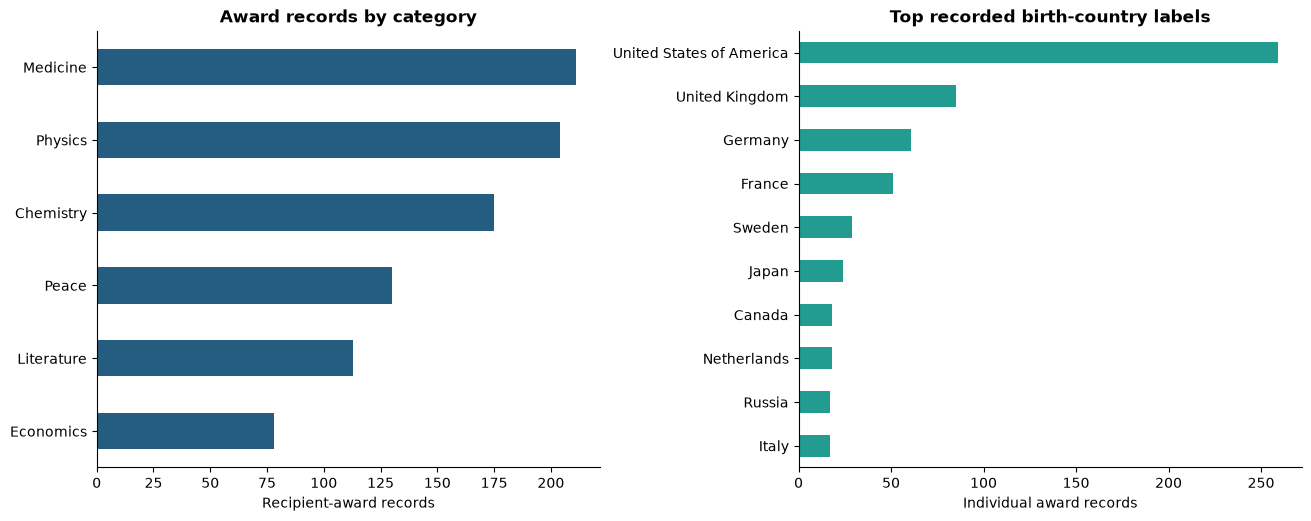

In [2]:
category_counts = nobel.category.value_counts()
birth_counts = people.birth_country.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5.1), layout="constrained")
category_counts.sort_values().plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title="Award records by category", xlabel="Recipient-award records", ylabel="")
birth_counts.head(10).sort_values().plot.barh(ax=axes[1], color=TEAL)
axes[1].set(title="Top recorded birth-country labels", xlabel="Individual award records", ylabel="")
fig.savefig("awards_and_birth_countries.png", dpi=160, facecolor="white")
plt.show()

## 3. Representation over time, with explicit denominators
US-born proportions use individual award records with known birth country. Female proportions use individual award records with a supplied Female/Male label. Organizations are excluded from both denominators; missing values are never silently counted as another group.

The first period covers **1901–1909**, and the last **2010–2016**. Intermediate periods cover ten calendar years. The category panels show gaps when no eligible records exist; a gap is not a zero. Percentages describe award records, so repeat laureates contribute more than once.

,US_records,Eligible_records,Proportion
decade,,,
1900,1,56,0.017857
1910,3,38,0.078947
1920,4,54,0.074074
1930,14,55,0.254545
1940,13,40,0.325000
1950,21,71,0.295775
1960,21,75,0.280000
1970,33,103,0.320388
1980,31,94,0.329787


,category,decade,Female_records,Eligible_records,Proportion
0,Chemistry,1900,0,9,0.000000
1,Chemistry,1910,1,8,0.125000
2,Chemistry,1920,0,10,0.000000
3,Chemistry,1930,1,13,0.076923
4,Chemistry,1940,0,9,0.000000
...,...,...,...,...,...
61,Physics,1970,0,25,0.000000
62,Physics,1980,0,22,0.000000
63,Physics,1990,0,22,0.000000
64,Physics,2000,0,28,0.000000


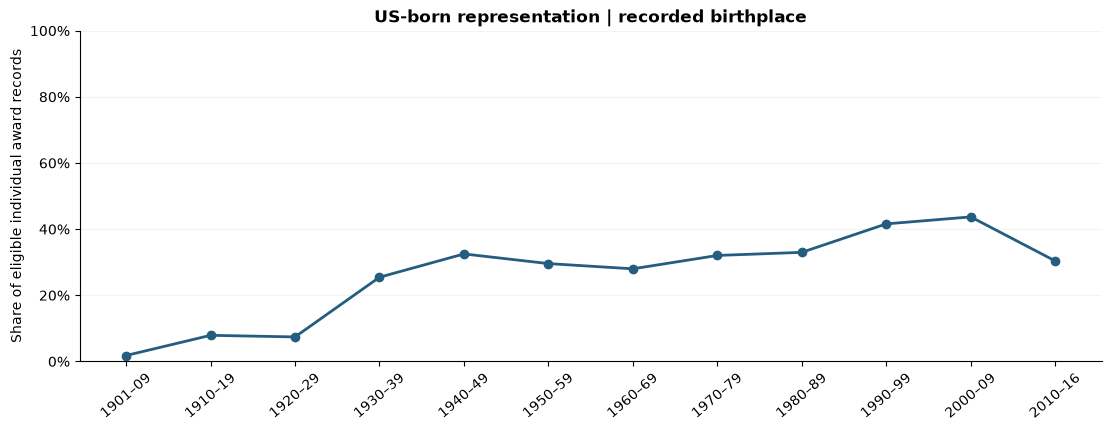

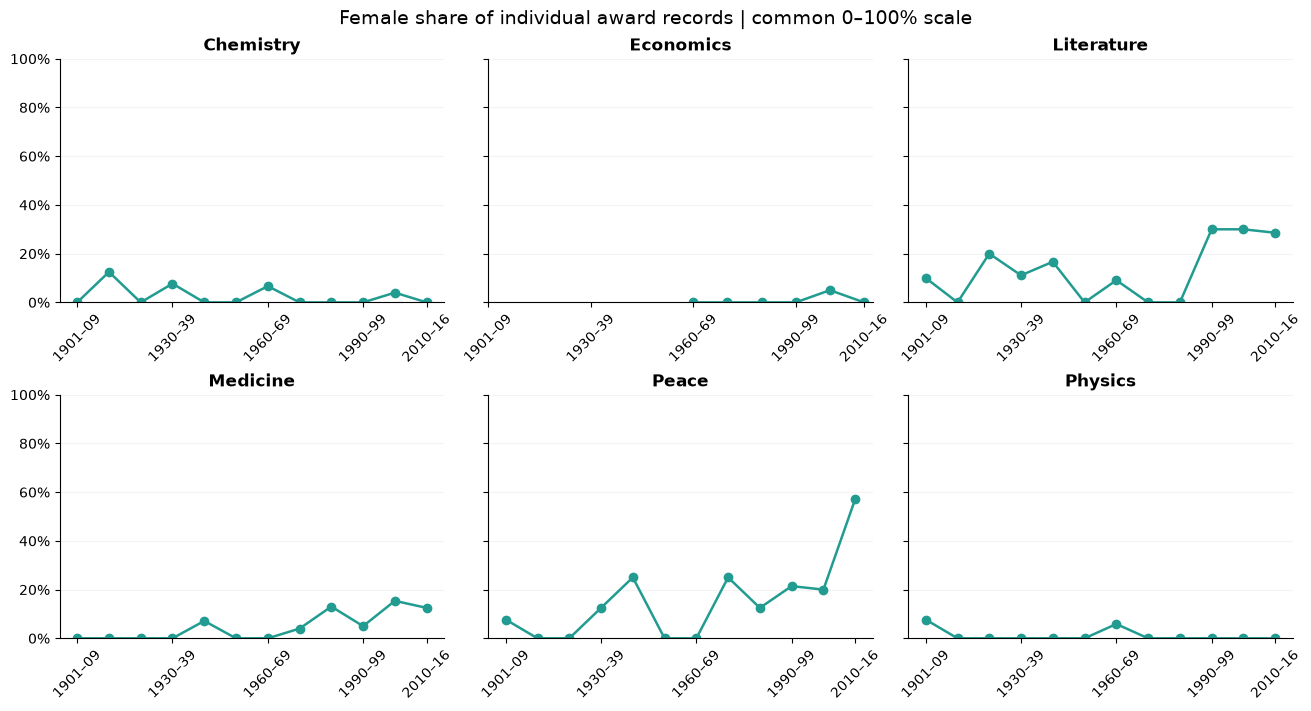

In [3]:
decades = list(range(1900, 2020, 10))
labels = ["1901–09"] + [f"{d}–{str(d+9)[2:]}" for d in decades[1:-1]] + ["2010–16"]
birth_known = people.dropna(subset=["birth_country"]).copy()
birth_known["us_born"] = birth_known.birth_country.eq("United States of America")
us_share = birth_known.groupby("decade").agg(US_records=("us_born","sum"), Eligible_records=("us_born","size"))
us_share["Proportion"] = us_share.US_records / us_share.Eligible_records
sex_known = people.loc[people.sex.isin(["Female","Male"])].copy()
sex_known["female"] = sex_known.sex.eq("Female")
female_share = sex_known.groupby(["category","decade"]).agg(Female_records=("female","sum"), Eligible_records=("female","size"))
female_share["Proportion"] = female_share.Female_records / female_share.Eligible_records
display(us_share)
display(female_share.reset_index())
fig, ax = plt.subplots(figsize=(11, 4.2), layout="constrained")
ax.plot(range(len(decades)), us_share.reindex(decades).Proportion, color=BLUE, marker="o", linewidth=2)
ax.set(xticks=range(len(decades)), xticklabels=labels, ylim=(0,1), ylabel="Share of eligible individual award records", title="US-born representation | recorded birthplace")
ax.tick_params(axis="x", rotation=40)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=.15)
fig.savefig("us_born_share.png", dpi=160, facecolor="white")
plt.show()
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True, layout="constrained")
for ax, category in zip(axes.flat, sorted(nobel.category.unique())):
    values = female_share.loc[category].reindex(decades)
    ax.plot(range(len(decades)), values.Proportion, color=TEAL, marker="o", linewidth=1.8)
    ax.set(title=category, ylim=(0,1), xticks=[0,3,6,9,11], xticklabels=[labels[i] for i in [0,3,6,9,11]])
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", alpha=.15)
fig.suptitle("Female share of individual award records | common 0–100% scale", fontsize=14)
fig.savefig("female_representation.png", dpi=160, facecolor="white")
plt.show()

## 4. Repeat laureates and the first recorded female award
Repeated names can be ambiguous, so repeat laureates are identified by **laureate ID**, with each year/category record counted once. Both people and organizations can repeat. The first female award is selected programmatically; all ties would be shown.

In [4]:
repeat_counts = nobel.groupby("laureate_id").size().loc[lambda x:x.gt(1)]
repeat_awards = nobel.loc[nobel.laureate_id.isin(repeat_counts.index)].sort_values(["laureate_id","year"])
display(repeat_awards[["laureate_id","full_name","laureate_type","year","category"]])
female_records = people.loc[people.sex.eq("Female")]
first_female = female_records.loc[female_records.year.eq(female_records.year.min())]
display(first_female[["full_name","year","category"]])
print(f"Repeat laureates: {len(repeat_counts)} IDs; highest count: {repeat_counts.max()} award records.")

,laureate_id,full_name,laureate_type,year,category
19,6,"Marie Curie, née Sklodowska",Individual,1903,Physics
62,6,"Marie Curie, née Sklodowska",Individual,1911,Chemistry
298,66,John Bardeen,Individual,1956,Physics
424,66,John Bardeen,Individual,1972,Physics
278,217,Linus Carl Pauling,Individual,1954,Chemistry
340,217,Linus Carl Pauling,Individual,1962,Peace
306,222,Frederick Sanger,Individual,1958,Chemistry
505,222,Frederick Sanger,Individual,1980,Chemistry
89,482,Comité international de la Croix Rouge (Intern...,Organization,1917,Peace
215,482,Comité international de la Croix Rouge (Intern...,Organization,1944,Peace


,full_name,year,category
19,"Marie Curie, née Sklodowska",1903,Physics


Repeat laureates: 6 IDs; highest count: 3 award records.


## 5. Approximate age at the award year
Age is **award year minus birth year**, not exact age on the announcement or ceremony date; the result can be one year higher than age on a particular date. Individuals without a parseable birth date are excluded only from age analyses, and their count is reported.

Each category panel shows individual award records and the median for each decade. These are descriptive summaries, not fitted forecasts or evidence about career opportunities. Shared prizes and repeat laureates affect the number of observations.

,category,decade,Median_age,Records
0,Chemistry,1900,50.0,9
1,Chemistry,1910,46.5,8
2,Chemistry,1920,53.0,10
3,Chemistry,1930,48.0,13
4,Chemistry,1940,55.0,9
...,...,...,...,...
61,Physics,1970,50.0,25
62,Physics,1980,60.0,22
63,Physics,1990,59.5,22
64,Physics,2000,69.5,28


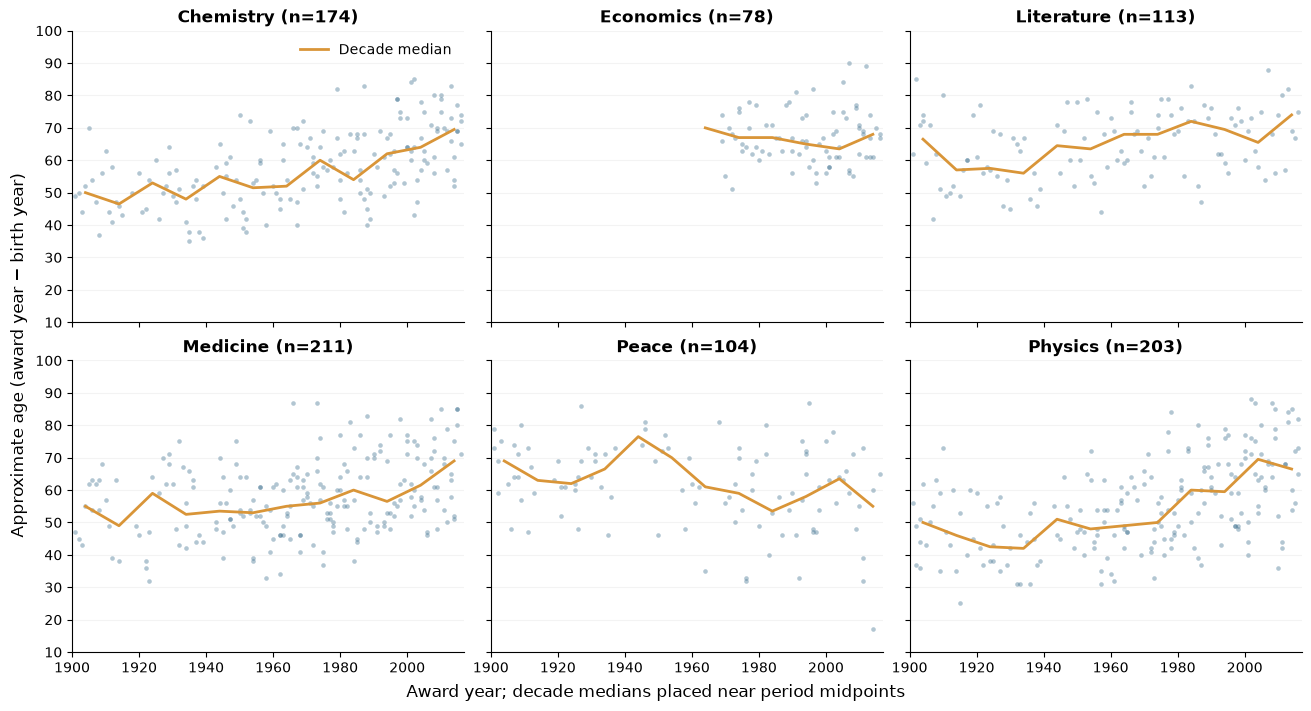

,Record,full_name,year,category,approx_age
885,Youngest in snapshot,Malala Yousafzai,2014,Peace,17.0
793,Oldest in snapshot,Leonid Hurwicz,2007,Economics,90.0


Female individual award records: 49 / 885 (5.5%).
Age coverage: 883 / 885 individual award records.


In [5]:
aged = people.dropna(subset=["approx_age"])
age_summary = aged.groupby(["category","decade"]).agg(Median_age=("approx_age","median"), Records=("approx_age","size"))
display(age_summary.reset_index())
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True, layout="constrained")
for ax, category in zip(axes.flat, sorted(nobel.category.unique())):
    values = aged.loc[aged.category.eq(category)]
    trend = age_summary.loc[category]
    ax.scatter(values.year, values.approx_age, s=11, color=BLUE, alpha=.35, linewidths=0)
    ax.plot(trend.index+4, trend.Median_age, color=GOLD, linewidth=2, label="Decade median")
    ax.set(title=f"{category} (n={len(values)})", ylim=(10,100), xlim=(1900,2017))
    ax.grid(axis="y", alpha=.15)
axes[0,0].legend(frameon=False)
fig.supylabel("Approximate age (award year − birth year)")
fig.supxlabel("Award year; decade medians placed near period midpoints")
fig.savefig("award_age_by_category.png", dpi=160, facecolor="white")
plt.show()
youngest = aged.loc[aged.approx_age.eq(aged.approx_age.min())]
oldest = aged.loc[aged.approx_age.eq(aged.approx_age.max())]
display(pd.concat([youngest.assign(Record="Youngest in snapshot"),oldest.assign(Record="Oldest in snapshot")])[["Record","full_name","year","category","approx_age"]])
print(f"Female individual award records: {len(female_records)} / {len(sex_known)} ({len(female_records)/len(sex_known):.1%}).")
print(f"Age coverage: {len(aged)} / {len(people)} individual award records.")

## Interpretation and provenance
Representation in this dataset cannot establish fairness or its causes. It lacks applicant and nomination denominators, broader career histories and other relevant context. Birth-country labels are historical, source sex categories are limited, and all conclusions stop at 2016. Some names contain encoding artifacts that are preserved rather than guessed.

Adapted from the supplied DataCamp Nobel Prize learning project. The original CSV is preserved unchanged. Four recipient-type corrections are explicit and linked to official references above; no sex, nationality or identity is inferred. Prize-share fractions are checked to sum to one for every year/category award, but descriptive charts give each recipient-award record equal weight. Source-data rights remain with their respective owners.